# **Part 1: Visualization & Exploratory Data Analysis (EDA)**

### **Dataset Introduction**

In this project, we will work with the Palmer Penguins dataset, which contains measurements of penguins observed on islands near Antarctica.

Please download the dataset [penguins.csv](https://drive.google.com/file/d/1dv8A8v_sdf29p1At40S7KBslJPmBA3e9/view?usp=sharing) or from canvas.

### **Dataset Description**

Each row represents a penguin, and columns include:

- species – Penguin species
- island – Island where the penguin was found
- bill_length_mm – Bill length (mm)
- bill_depth_mm – Bill depth (mm)
- flipper_length_mm – Flipper length (mm)
- body_mass_g – Body mass (grams)
- sex – Sex of the penguin

Some values are missing, which makes this dataset ideal for practicing missing data handling.



Your task is to perform a comprehensive Exploratory Data Analysis (EDA) and visualization on the Palmer Penguins dataset. This project aims to deepen your understanding of data characteristics, relationships between variables, and effective data presentation using Python's data science libraries.

**Instructions:**

1.  **Load the Dataset:** Begin by loading the `penguins.csv` dataset into a pandas DataFrame.
2.  **Initial Data Inspection:** Perform an initial inspection to understand the dataset's structure. Display the first few rows, check data types and non-null values, and generate descriptive statistics.
3.  **Handle Missing Values:** Identify and address any missing values in the dataset. Clearly explain your chosen strategy for handling missing data (e.g., imputation, dropping rows/columns) and justify your decision.
4.  **Perform EDA and Visualization:** Conduct a thorough EDA, exploring distributions, relationships, and patterns within the data. You are required to use **at least three distinct types of visualizations** (e.g., histograms, scatter plots, box plots, bar charts). For each visualization:
    *   Justify your choice of plot type, explaining why it is suitable for the variables being analyzed.
    *   Clearly articulate what insights each visualization reveals about the data (e.g., distributions, correlations, outliers, group differences).
5.  **Summarize Key Findings:** Based on your EDA and visualizations, summarize the most important insights and observations about the Palmer Penguins dataset. Highlight any discovered patterns, trends, anomalies, or interesting relationships.
6.  **Final Task:** Present your complete EDA and visualization analysis, emphasizing key takeaways and interpretations of the observed data characteristics and relationships in a clear and concise manner.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("penguins.csv")

In [3]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [5]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [6]:
filtered_df = df.dropna(axis=1, how='all') # I decided to drop all na values because as df.info() told me there are few rows with na values. Meaning it is safe to drop them

In [7]:
filtered_df.corr(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


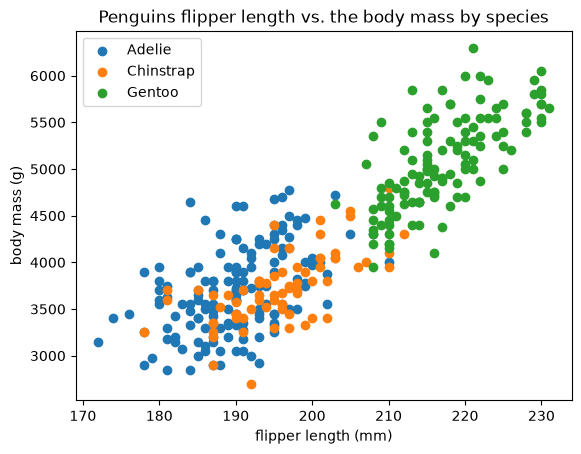

In [8]:
temp = filtered_df.groupby("species")
for species, group in temp:
    plt.scatter(group["flipper_length_mm"], group["body_mass_g"], label=species)
plt.title("Penguins flipper length vs. the body mass by species")
plt.xlabel("flipper length (mm)")
plt.ylabel("body mass (g)")
plt.legend()
# I chose to plot the flipper length vs. the body mass because filtered_df.corr() told me there was a strong correlation between the two variables.
# From plotting the scatter plot I found out that the correlation is close to linear. And The species also is strongly correlated with the body mass, and flipper length.

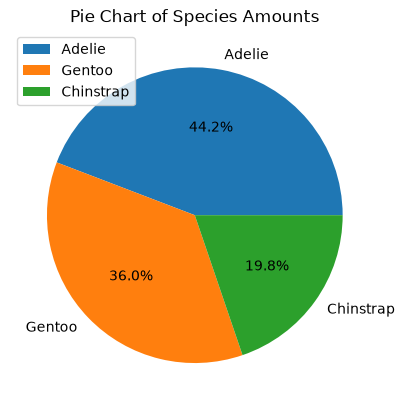

In [20]:
plt.pie(filtered_df["species"].value_counts(), labels=filtered_df["species"].value_counts().index, autopct='%1.1f%%')
plt.title("Pie Chart of Species Amounts")
plt.legend(loc="upper left")
# I chose to plot the pie chart of the data so I could better understand the dataset and figure out which species were recorded the most.
# I found out that the Adelie species wass recorded the most followed by the chinstrap, with the gentoo in last with less than 20% of the dataset deticated to them.

island
Torgersen    52
Biscoe       44
Dream        56
Name: count, dtype: int64 152
island
Torgersen     NaN
Biscoe        NaN
Dream        68.0
Name: count, dtype: float64 68
island
Torgersen      NaN
Biscoe       124.0
Dream          NaN
Name: count, dtype: float64 124


Text(0, 0.5, 'Number of sightings')

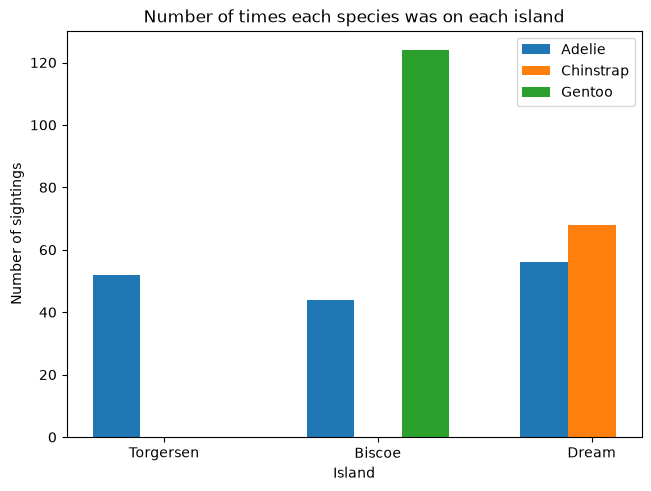

In [14]:
temp = filtered_df.groupby("species")
fig, ax = plt.subplots(layout='constrained')
all_islands = filtered_df["island"].unique()
islands = {}
for species, group in temp:
    islandCount = group["island"].value_counts().reindex(all_islands)
    islands[species] = islandCount
    print(islandCount, group["species"].count())
ax.grouped_bar(islands, tick_labels=all_islands)
plt.legend(loc="upper right")
plt.title("Number of times each species was on each island")
plt.xlabel("Island")
plt.ylabel("Number of sightings")
# I was curious how often the species were near each other. So I plotted the count of the times each species was on each island.
# I found out that the Adelies hang around every island while the Gentooss are exclusivly native to the Biscoe island and the Dream species is exclusive to Dream island

# Key findings and final analysis

I started by getting to understand the dataset by looking at the dtypes and the number of na values. I then looked at the correlation between the numeric columns, and the high correlation between the flipper length, and the body mass. I decided to plot the data out of curiosity, the plot also seperated out the data based on species. I confirmed the correlaton and noted that the species also seem to affect both the body mass and flipper length. After seeing the diffrence in species I wanted to get a better idea of the species in the dataset so I ploted a pie chart of the species, which told me the dataset was mostly made of the Adelie species, with few Chinstrap species documented. I also wanted to see if there was room for diffrent species to interact with each otheer, so I plotted a barchart based on the number of observations of each species seperated by island. This showed me that the Adelie species live everywhere, whilst the other two species are native to only one island each. 